<a href="https://colab.research.google.com/github/Springale/springale/blob/main/ZeroGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Steps:
1. Loads issue data from a JSON file
2. Sends text to ZeroGPT API for AI detection
3. Extracts relevant metrics (AI percentage, feedback label, word count, etc.)
4. Stores results in a DataFrame
5. Visualizes and exports results (CSV + Excel)

In [ ]:
!pip install requests pandas tqdm openpyxl --quiet

In [ ]:
%%writefile issues.json
[
  {
    "id": 201,
    "title": "Mobile Safari sometimes fails to log in after a session times out.",
    "body": "People say that when they try to log back in with Safari on iOS after their session has ended, they get a blank screen with no error message. The problem doesn't happen all the time, and it seems to have something to do with cookies or not clearing session storage properly. When the network connection changes from WiFi to cellular data, attempts to reproduce happen more often.",
    "labels": ["bug", "frontend", "ios", "high priority"]
  },
  {
    "id": 202,
    "title": "When there are a lot of people using it, dashboard analytics takes longer to load.",
    "body": "During peak traffic hours (about 6 p.m. to 10 p.m. UTC), the time it takes for the dashboard to load goes up a lot. It can take 12 to 18 seconds to fix some requests. Initial profiling suggests repeated API calls triggered on component mount and missing caching for user-specific aggregation queries. Database indexes may also be suboptimal.",
    "labels": ["performance", "backend", "database"]
  },
  {
    "id": 203,
    "title": "User profile updates not propagating across services",
    "body": "Updating user profile fields such as email, avatar, or display name does not always reflect in downstream services. Notifications sometimes show stale values. Analytics pipeline appears delayed. Suspected issue in event bus or message queue consumer lag.",
    "labels": ["bug", "backend", "data-consistency"]
  },
  {
    "id": 204,
    "title": "Curl TLS connection reuse ignores security option changes",
    "body": "Curl does not correctly re-evaluate certain security related options when reusing TLS connections. Options such as CURLOPT_SSL_OPTIONS, CURLOPT_PROXY_SSL_OPTIONS, CURLOPT_CRLFILE, and CURLOPT_PROXY_CRLFILE may be ignored during connection reuse. As a result, connections established with lower security settings (for example CURLSSLOPT_ALLOW_BEAST or CURLSSLOPT_NO_REVOKE) may be reused even when later requests require stricter security policies. Similarly, connections authenticated with CURLSSLOPT_AUTO_CLIENT_CERT may be reused in contexts where client authentication should not apply.\n\nSteps to reproduce:\nA server is started that responds with simple HTTP responses over TLS. A curl client performs multiple requests to the same endpoint with differing security flags such as --ssl-no-revoke and --ssl-allow-beast. Despite changes in security configuration between requests, curl continues to reuse the same TLS session.\n\nImpact:\nThis may result in incorrect identity usage, such as unintended client certificate reuse, or weaker TLS settings being applied to requests that expect stricter security enforcement. This creates a risk of policy bypass in environments where per-request TLS configuration is expected to be enforced.",
    "labels": ["bug", "security", "tls", "curl"]
  },
  {
    "id": 205,
    "title": "Token expiration breaks UI state unexpectedly",
    "body": "When JWT expires mid-session, the frontend continues rendering partially authenticated views. API calls begin failing silently, leading to inconsistent UI states. Users are not redirected to login and no global handler catches the 401 response.",
    "labels": ["auth", "frontend", "bug"]
  },

  {
    "id": 206,
    "title": "AI-generated weekly engagement report spec",
    "body": "Generate a structured weekly report summarizing platform usage. Include: average session duration, top features used, anomaly detection for spikes in traffic, and predicted engagement for the next week using historical trends. Output should be suitable for admin dashboard ingestion.",
    "labels": ["ai", "reporting", "feature"]
  },

  {
    "id": 207,
    "title": "checksrc macro bypass allows banned function to evade detection",
    "body": "checksrc.pl fails to detect banned functions when macro line continuations are used. The regex expects function name and '(' on same logical line, but backslash continuation breaks detection.\n\nExample:\n#define TEST(x) \\\n    malloc \\\n    (x)\n\nRoot cause: line-by-line parsing loses macro context. The regex ^(.*?\\W)(\\w+)(\\s*\\() does not reconstruct logical lines before evaluation.\n\nEnvironment: curl master, perl 5.34",
    "labels": ["lint", "security", "static-analysis"]
  },

  {
    "id": 208,
    "title": "Hypothetical CMake variable lifecycle issue in FindMbedTLS",
    "body": "While reviewing FindMbedTLS.cmake, a lifecycle inconsistency may exist where MBEDTLS_INCLUDE_DIRS is migrated to MBEDTLS_INCLUDE_DIR and then unset. Downstream logic relies on derived variable _mbedtls_INCLUDE_DIRS which may not always be reinitialized correctly.\n\nPotential risk: empty include directories or fallback to system headers in mixed environments.\n\nThis is a conceptual issue based on variable flow analysis and not confirmed runtime behavior.",
    "labels": ["cmake", "build-system", "analysis"]
  },

  {
    "id": 209,
    "title": "Segmentation fault during repeated HTTPS cleanup with mbedTLS",
    "body": "Repeated curl_easy_perform calls eventually crash during SSL teardown. Crash occurs inside mbedtls_ssl_free after many successful requests.\n\nStack trace indicates failure in vtls cleanup path:\n#0 mbedtls_ssl_free\n#1 mbed_close\n#2 Curl_ssl_close\n#3 Curl_disconnect\n\nSwitching to OpenSSL eliminates issue.\nHypothesis: possible double free or invalid pointer during session reuse cleanup.",
    "labels": ["crash", "tls", "mbedtls", "high priority"]
  },

  {
    "id": 210,
    "title": "HTML title extraction prints unsanitized output (potential XSS)",
    "body": "htmltitle.cpp extracts the <title> tag from remote HTML using libxml and prints it directly using printf without sanitization.\n\nExample vulnerable line:\nprintf(\"Title: %s\\n\", title.c_str());\n\nIf input HTML contains:\n<title><script>alert('XSS')</script></title>\n\nThen output becomes:\nTitle: <script>alert('XSS')</script>\n\nIf this output is rendered in a web-based dashboard or log viewer, it could lead to XSS (CWE-79). Terminal injection via escape sequences is also possible.\n\nMitigation: escape HTML entities before printing and validate control characters.",
    "labels": ["security", "CWE-79", "output-sanitization"]
  },

  {
    "id": 211,
    "title": "Inconsistent caching behavior causes random stale API responses",
    "body": "Sometimes API returns stale data even after cache invalidation. This happens mostly under high concurrency. Observed behavior suggests race condition between cache write and invalidation layer. Hard to reproduce consistently, but more frequent in production than staging.",
    "labels": ["bug", "cache", "backend"]
  },

  {
    "id": 212,
    "title": "Refactor request: unify error handling across service boundaries",
    "body": "We currently have inconsistent error formats across services. Some return JSON with 'error', others use HTTP-only status codes. Proposal: standardize response schema to include {code, message, traceId}. This would improve observability and debugging.",
    "labels": ["refactor", "architecture", "backend"]
  }
]

Overwriting issues.json


In [ ]:
from google.colab import userdata

# ZEROGPT_API_KEY = userdata.get("zerogpt")
ZEROGPT_API_KEY = userdata.get("ZeroGPT_API_Key")

if not ZEROGPT_API_KEY:
    raise ValueError("ZEROGPT_API_KEY not found in Colab Secrets")

JSON_FILE_PATH = "issues.json"
TEXT_FIELD = "body"
COMBINE_TITLE_AND_BODY = True
DELAY_BETWEEN_REQUESTS_SEC = 6
OUTPUT_CSV  = "zerogpt_results.csv"
OUTPUT_XLSX = "zerogpt_results.xlsx"

In [ ]:
import json
import pandas as pd

# read and store the file
with open(JSON_FILE_PATH, "r", encoding="utf-8") as f:
    raw = json.load(f)

# normalize data structure
if isinstance(raw, list):
    issues = raw
elif isinstance(raw, dict):
    lists = [v for v in raw.values() if isinstance(v, list)]
    if not lists:
        raise ValueError("No list of issues found in JSON structure")
    issues = lists[0]
else:
    raise ValueError("Invalid JSON format")

print(f"Loaded {len(issues)} issues")
print("\nSchema (first entry):")
for k, v in issues[0].items():
    print(f"  {k:<25} {type(v).__name__:<10}  sample: {str(v)[:60]}")

# Example output of the above:
# id                      int        sample: 12345
# title                   str        sample: Fix login bug
# labels                  list       sample: ['bug', 'urgent']

Loaded 12 issues

Schema (first entry):
  id                        int         sample: 201
  title                     str         sample: Mobile Safari sometimes fails to log in after a session time
  body                      str         sample: People say that when they try to log back in with Safari on 
  labels                    list        sample: ['bug', 'frontend', 'ios', 'high priority']


In [ ]:
import os, hashlib
import time

CACHE_FILE = "cache_zerogpt.json"

if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, "r") as f:
        cache = json.load(f)
else:
    cache = {}

In [ ]:
import requests, time

ZEROGPT_URL = "https://api.zerogpt.com/api/detect/detectText"

def call_zerogpt(text, api_key):
    headers = {
        "Content-Type": "application/json",
        "ApiKey": api_key
    }

    resp = session.post(
        ZEROGPT_URL,
        json={"input_text": text},
        headers=headers,
        timeout=30
    )

    try:
        return resp.json()
    except Exception:
        return {
            "error": resp.text,
            "status": resp.status_code
        }

def call_with_retry(text, retries=3):
    for i in range(retries):
        result = call_zerogpt(text, ZEROGPT_API_KEY)

        if "error" not in result:
            return result

        time.sleep(2 ** i)  # 1s, 2s, 4s

    return {"error": "failed after retries"}

def get_cached_or_call(text):
    key = hashlib.md5(text.encode()).hexdigest()

    if key in cache:
        return cache[key]

    result = call_with_retry(text)
    cache[key] = result
    return result

# Takes API response and extracts only important metrics into a structured dictionary
def extract_fields(response):

    if not isinstance(response, dict):
        return {"zg_error": f"invalid response type: {type(response)}"}

    if not response.get("success"):
        return {"zg_error": response.get("message") or "request failed"}

    data = response.get("data", {})

    fake_pct = data.get("fakePercentage")

    return {
        "zg_ai_percentage": fake_pct,
        "zg_human_percentage": (100 - fake_pct) if fake_pct is not None else None,
        "zg_ai_words": data.get("aiWords"),
        "zg_word_count": data.get("textWords"),
        "zg_additional_feedback": data.get("h"),
    }

In [ ]:
from tqdm.notebook import tqdm # progress bar for loops (shows % completed)
from concurrent.futures import ThreadPoolExecutor, as_completed

# This list will store all processed results from ZeroGPT
# Each "row" represents one issue + its AI detection results
records = []

# Loop through all issues with a progress bar
def process_issue(issue):
    title = issue.get("title", "")
    body  = issue.get("body", "") or ""

    if COMBINE_TITLE_AND_BODY:
        text = f"{title}\n\n{body}".strip()
    else:
        text = body

    if not text.strip():
        return {"id": issue.get("id"), "zg_error": "empty text"}

    response = get_cached_or_call(text)
    extracted = extract_fields(response)

    return {
        "id": issue.get("id"),
        "title": title,
        "labels": ", ".join(issue.get("labels", [])),
        "text_len": len(text),
        "text_preview": text[:120].replace("\n", " "),
        **extracted
    }

records = [None] * len(issues)

with ThreadPoolExecutor(max_workers=8) as executor:
    future_to_index = {
        executor.submit(process_issue, issue): i
        for i, issue in enumerate(issues)
    }

    for future in tqdm(as_completed(future_to_index), total=len(issues), desc="ZeroGPT"):
        i = future_to_index[future]
        records[i] = future.result()

df = pd.DataFrame(records)

with open(CACHE_FILE, "w") as f:
    json.dump(cache, f)

df

ZeroGPT:   0%|          | 0/12 [00:00<?, ?it/s]

,id,title,labels,text_len,text_preview,zg_ai_percentage,zg_human_percentage,zg_ai_words,zg_word_count,zg_additional_feedback
0,201,Mobile Safari sometimes fails to log in after ...,"bug, frontend, ios, high priority",447,Mobile Safari sometimes fails to log in after ...,61.0,39.0,67,79,[People say that when they try to log back in ...
1,202,"When there are a lot of people using it, dashb...","performance, backend, database",425,"When there are a lot of people using it, dashb...",20.5,79.5,25,73,"[When there are a lot of people using it, dash..."
2,203,User profile updates not propagating across se...,"bug, backend, data-consistency",308,User profile updates not propagating across se...,0.0,100.0,0,44,[]
3,204,Curl TLS connection reuse ignores security opt...,"bug, security, tls, curl",1293,Curl TLS connection reuse ignores security opt...,70.7,29.3,146,169,[Curl does not correctly re-evaluate certain s...
4,205,Token expiration breaks UI state unexpectedly,"auth, frontend, bug",291,Token expiration breaks UI state unexpectedly ...,0.0,100.0,0,41,[]
5,206,AI-generated weekly engagement report spec,"ai, reporting, feature",327,AI-generated weekly engagement report spec Ge...,0.0,100.0,0,44,[]
6,207,checksrc macro bypass allows banned function t...,"lint, security, static-analysis",482,checksrc macro bypass allows banned function t...,0.0,100.0,0,64,[]
7,208,Hypothetical CMake variable lifecycle issue in...,"cmake, build-system, analysis",515,Hypothetical CMake variable lifecycle issue in...,0.0,100.0,0,66,[]
8,209,Segmentation fault during repeated HTTPS clean...,"crash, tls, mbedtls, high priority",448,Segmentation fault during repeated HTTPS clean...,0.0,100.0,0,56,[]
9,210,HTML title extraction prints unsanitized outpu...,"security, CWE-79, output-sanitization",624,HTML title extraction prints unsanitized outpu...,26.2,73.8,23,77,"[printf(""Title: %s\n"", title.c_str());, Title:..."


=== ZeroGPT Summary ===
Mean AI%: 14.9  Median: 0.0  Min: 0.0  Max: 70.7
zg_additional_feedback
[]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

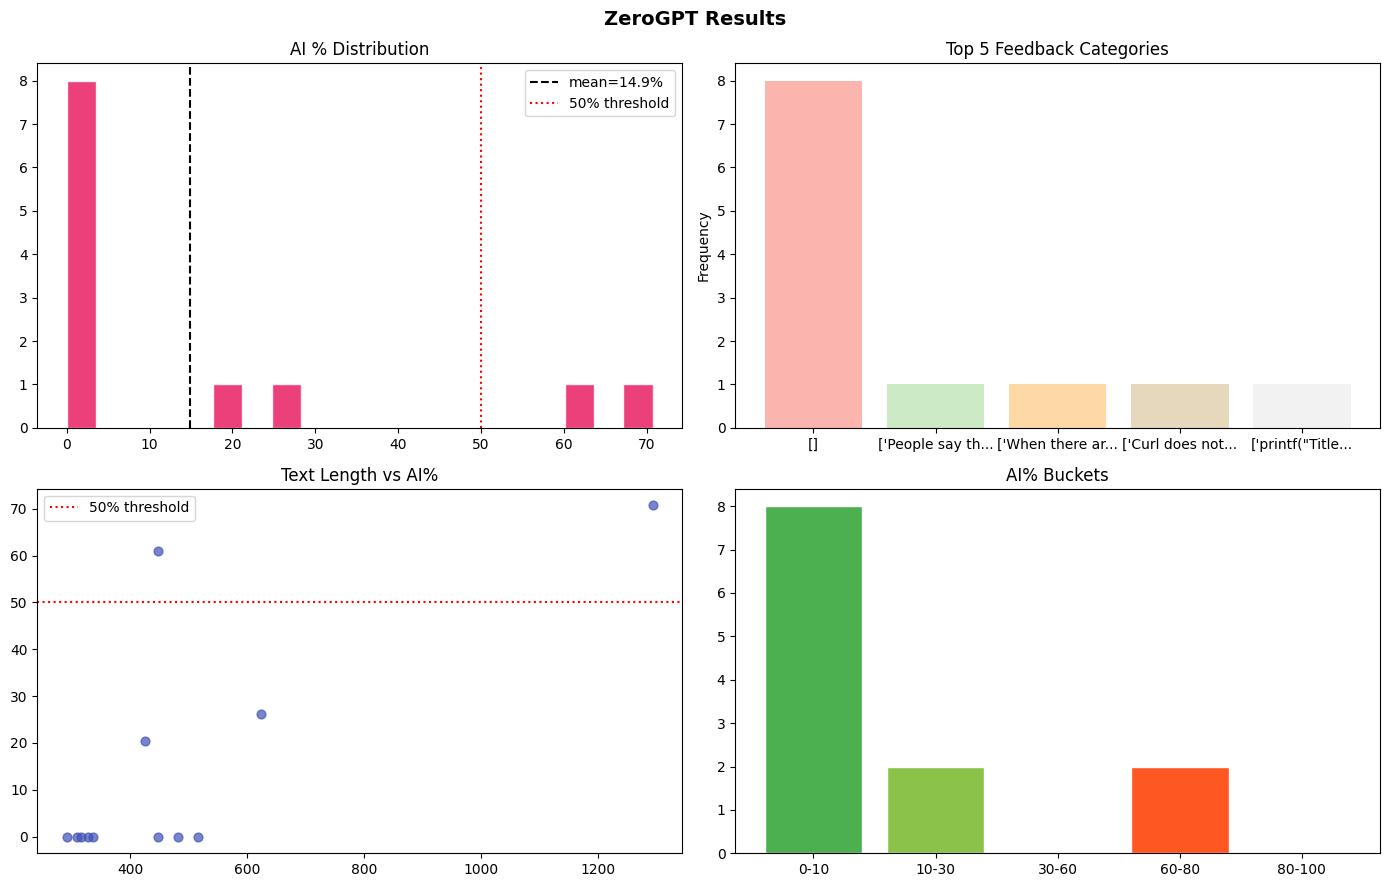

Saved zerogpt_results.csv and zerogpt_results.xlsx


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("=== ZeroGPT Summary ===")

if "zg_ai_percentage" in df.columns:
    vals = df["zg_ai_percentage"].dropna()
    print(f"Mean AI%: {vals.mean():.1f}  Median: {vals.median():.1f}  Min: {vals.min():.1f}  Max: {vals.max():.1f}")

if "zg_additional_feedback" in df.columns:
    print(df["zg_additional_feedback"].value_counts(dropna=False))

numeric = ["zg_ai_percentage", "zg_input_words"]
print(df[[c for c in numeric if c in df.columns]].describe().round(4))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("ZeroGPT Results", fontsize=14, fontweight="bold")

# AI% histogram
ax = axes[0,0]
if "zg_ai_percentage" in df.columns:
    vals = df["zg_ai_percentage"].dropna()
    ax.hist(vals, bins=20, color="#E91E63", edgecolor="white", alpha=0.85)
    ax.axvline(vals.mean(), color="black", linestyle="--", label=f"mean={vals.mean():.1f}%")
    ax.axvline(50, color="red", linestyle=":", label="50% threshold")
    ax.set_title("AI % Distribution"); ax.legend()

# Feedback labels bar chart (Improved)
ax = axes[0,1]
if "zg_additional_feedback" in df.columns:
    # Only take the top 5 most common feedback messages
    counts = df["zg_additional_feedback"].value_counts(dropna=False).head(5)

    # Truncate labels so they don't bleed over the whole image
    labels = [str(i)[:15] + "..." if len(str(i)) > 15 else str(i) for i in counts.index]

    ax.bar(labels, counts.values, color=plt.cm.Pastel1(np.linspace(0,1,len(counts))))
    ax.set_title("Top 5 Feedback Categories")
    ax.set_ylabel("Frequency")

# Scatter: length vs AI%
ax = axes[1,0]
if "zg_ai_percentage" in df.columns:
    s = df[["text_len", "zg_ai_percentage"]].dropna()
    ax.scatter(s["text_len"], s["zg_ai_percentage"], alpha=0.7, color="#3F51B5", s=40)
    ax.axhline(50, color="red", linestyle=":", label="50% threshold")
    ax.set_title("Text Length vs AI%"); ax.legend()

# AI% buckets bar
ax = axes[1,1]
if "zg_ai_percentage" in df.columns:
    vals = df["zg_ai_percentage"].dropna()
    buckets = pd.cut(vals, bins=[0,10,30,60,80,100], labels=["0-10","10-30","30-60","60-80","80-100"], include_lowest=True)
    b = buckets.value_counts().sort_index()
    ax.bar(b.index.astype(str), b.values, color=["#4CAF50","#8BC34A","#FF9800","#FF5722","#F44336"], edgecolor="white")
    ax.set_title("AI% Buckets")

plt.tight_layout()
plt.savefig("zerogpt_plots.png", dpi=150)
plt.show()

df.to_csv(OUTPUT_CSV, index=False)
df.to_excel(OUTPUT_XLSX, index=False)
print(f"Saved {OUTPUT_CSV} and {OUTPUT_XLSX}")

In [ ]:
import requests

def zerogpt_login(email, password):
    url = f"{BASE_URL}/api/auth/login"

    resp = requests.post(
        url,
        json={
            "email": email,
            "password": password
        },
        timeout=30
    )

    # 1. ensure we actually got JSON
    try:
        data = resp.json()
    except Exception:
        raise Exception(
            f"Login failed: non-JSON response (status {resp.status_code})\n"
            f"{resp.text[:500]}"
        )

    # 2. handle HTTP-level errors
    if resp.status_code != 200:
        raise Exception(
            f"Login HTTP error {resp.status_code}: {data}"
        )

    # 3. handle API-level failure
    if not data.get("success"):
        raise Exception(f"Login failed: {data.get('message')}")

    # 4. safely extract token (handles slight schema variation)
    token = (
        data.get("data", {}).get("token")
        or data.get("token")
    )

    if not token:
        raise Exception(f"No token found in response: {data}")

    return token